<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Fama%2C%20Eugene%20F.%20(1970).%20Efficient%20Capital%20Markets%20A%20Review%20of%20Theory%20and%20Empirical%20Work/Efficient_Markets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
import yfinance as yf
np.random.seed(42)


The efficient‑market hypothesis paper shows that if markets are at least weak‑form efficient, prices behave like a random walk. This means that they incorporate all available information and that future price changes are unpredictable based on past information.

[*********************100%***********************]  1 of 1 completed


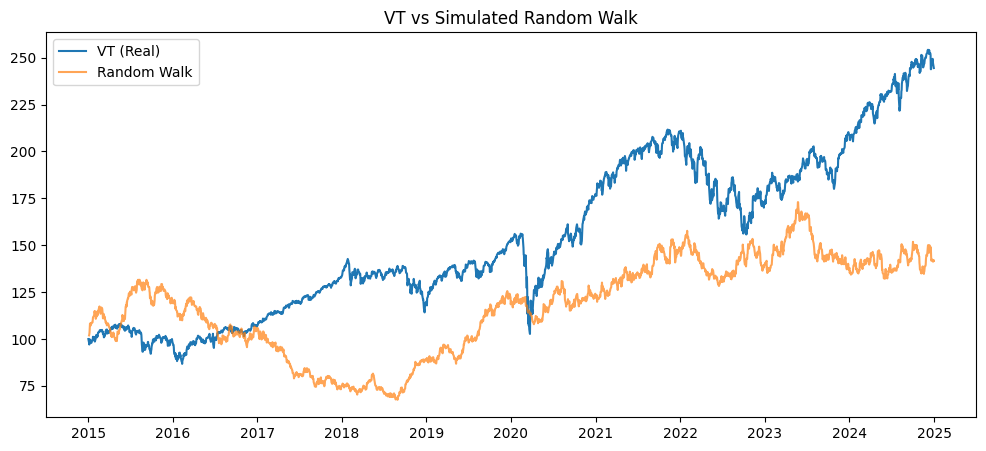

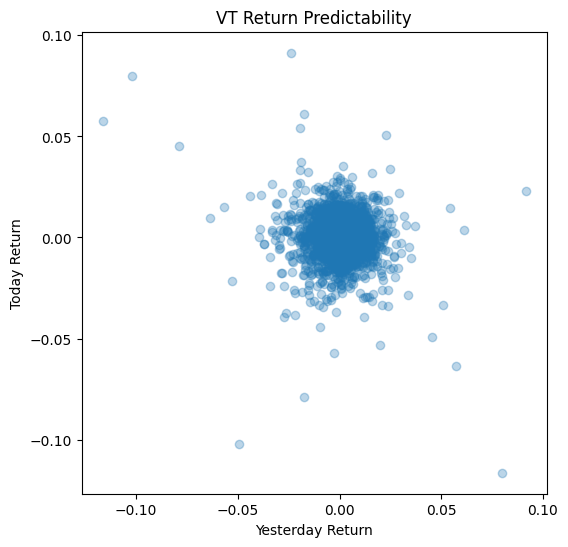

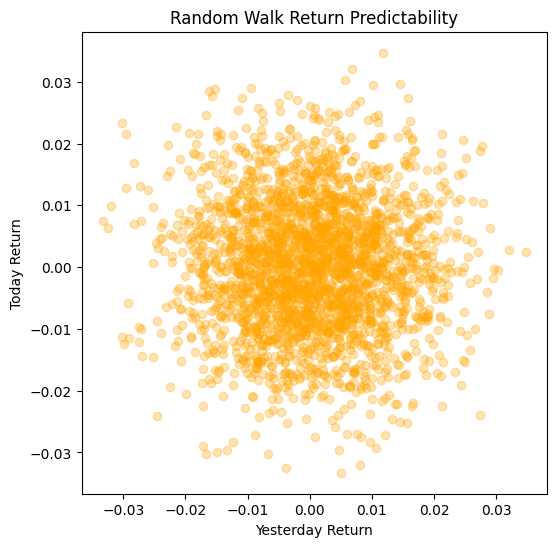

In [2]:


# --- Load VT data ---
vt = yf.download("VT", start="2015-01-01", end="2025-01-01", auto_adjust=True)
prices = vt["Close"]

# --- Compute returns ---
returns = prices.pct_change().dropna()

# --- Simulate random walk with same mean/std ---
np.random.seed(0)
sim_returns = np.random.normal(returns.mean(), returns.std(), len(returns))
sim_prices = 100 * (1 + sim_returns).cumprod()

# --- Plot prices vs random walk ---
plt.figure(figsize=(12,5))
plt.plot(prices.index, prices / prices.iloc[0] * 100, label="VT (Real)")
plt.plot(prices.index[1:], sim_prices, label="Random Walk", alpha=0.7)
plt.title("VT vs Simulated Random Walk")
plt.legend()
plt.show()

# --- Scatter: today's vs yesterday's returns ---
plt.figure(figsize=(6,6))
plt.scatter(returns[:-1], returns[1:], alpha=0.3)
plt.xlabel("Yesterday Return")
plt.ylabel("Today Return")
plt.title("VT Return Predictability")
plt.show()


# --- Scatter: Simulated today's vs yesterday's returns ---
plt.figure(figsize=(6,6))
plt.scatter(sim_returns[:-1], sim_returns[1:], color='orange', alpha=0.3)
plt.xlabel("Yesterday Return")
plt.ylabel("Today Return")
plt.title("Random Walk Return Predictability")
plt.show()

The scatter plot of daily returns for the Vanguard Total World Stock ETF forms a tight, patternless cloud centered around (0,0). There is no visible slope or structure, and both large and small returns are scattered randomly. This lack of discernible pattern indicates that today’s returns show little to no dependence on yesterday’s returns, highlighting that returns are largely unpredictable and exhibit minimal autocorrelation.

[*********************100%***********************]  1 of 1 completed


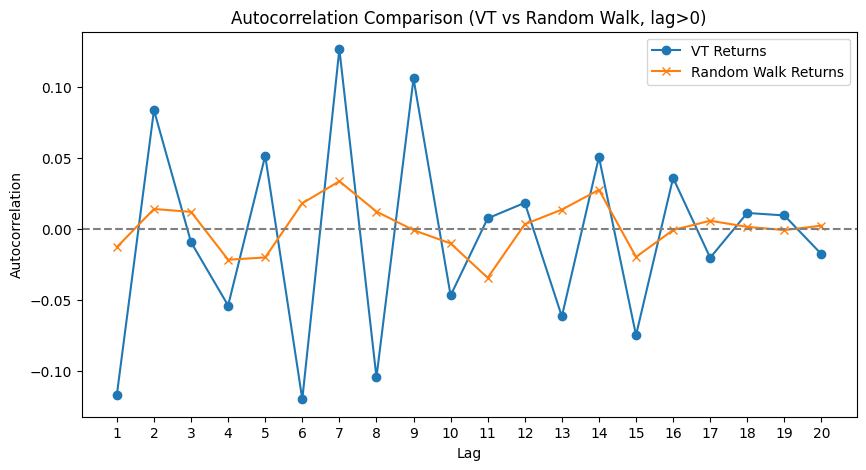

In [3]:

# --- Load VT data ---
vt = yf.download("VT", start="2015-01-01", end="2025-01-01", auto_adjust=True)
prices = vt["Close"]
returns = prices.pct_change().dropna()

# --- Simulate random walk returns ---
np.random.seed(0)
sim_returns = np.random.normal(returns.mean(), returns.std(), len(returns))

# --- Compute autocorrelations (lag 1 onwards) ---
lags = 20
acf_real = acf(returns, nlags=lags)[1:]  # skip lag 0
acf_sim = acf(sim_returns, nlags=lags)[1:]  # skip lag 0

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(range(1, lags+1), acf_real, marker='o', label="VT Returns")
plt.plot(range(1, lags+1), acf_sim, marker='x', label="Random Walk Returns")

plt.axhline(0, linestyle='--', color='gray')
plt.xticks(range(1, lags+1))
plt.title("Autocorrelation Comparison (VT vs Random Walk, lag>0)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.legend()
plt.show()

The autocorrelation plot of daily returns for the Vanguard Total World Stock ETF shows values hovering close to zero across all lags, partially resembling the autocorrelation pattern of a simulated random walk. This similarity highlights how VT’s daily returns behave in a manner partially consistent with random-walk-like behavior.

[*********************100%***********************]  1 of 1 completed


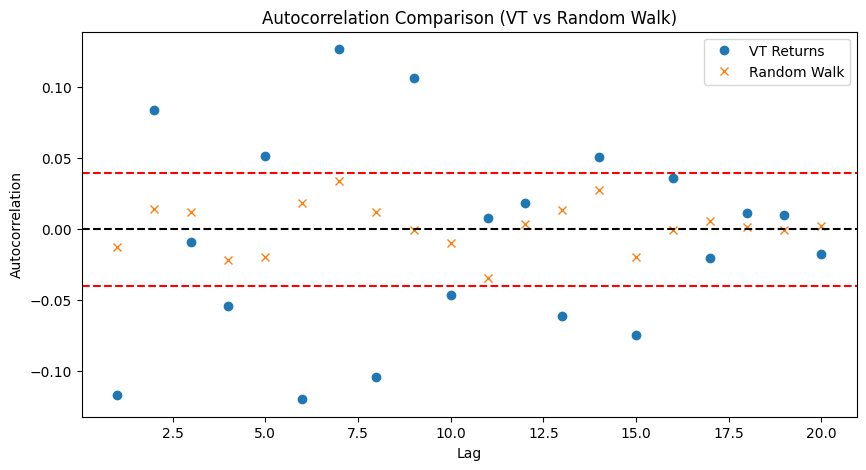

Approx. 95% significance level: ±0.0399
Percentage of VT autocorrelations significant: 60.0%


In [4]:

# Load VT returns
vt = yf.download("VT", start="2015-01-01", end="2025-01-01", auto_adjust=True)["Close"].pct_change().dropna()

# Simulate random walk
np.random.seed(0)
sim = np.random.normal(vt.mean(), vt.std(), len(vt))

# Autocorrelations (skip lag 0)
lags = 20
acf_vt = acf(vt, nlags=lags)[1:]
acf_sim = acf(sim, nlags=lags)[1:]

# Significance level
conf = 2 / np.sqrt(len(vt))

# Plot
plt.figure(figsize=(10,5))
plt.plot(range(1,lags+1), acf_vt, 'o', label="VT Returns")
plt.plot(range(1,lags+1), acf_sim, 'x', label="Random Walk")
plt.axhline(0, color='black', linestyle='--')
plt.axhline(conf, color='red', linestyle='--')
plt.axhline(-conf, color='red', linestyle='--')
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Comparison (VT vs Random Walk)")
plt.legend()
plt.show()

print(f"Approx. 95% significance level: ±{conf:.4f}")

# Calculate percentage of significant VT autocorrelations
significant = np.abs(acf_vt) > conf
percent_significant = 100 * np.sum(significant) / len(acf_vt)
print(f"Percentage of VT autocorrelations significant: {percent_significant:.1f}%")

The significance level shows how large an autocorrelation needs to be to be unlikely due to random chance.

This shows that VT does not perfectly follow a random walk, because 60% of the first 20 lags show statistically significant autocorrelations. This indicates some short-term predictability, meaning past returns contain information about future returns. While weak-form market efficiency would imply mostly random returns, in real markets small deviations like this are common due to microstructure effects or delayed reactions.

[*********************100%***********************]  1 of 1 completed


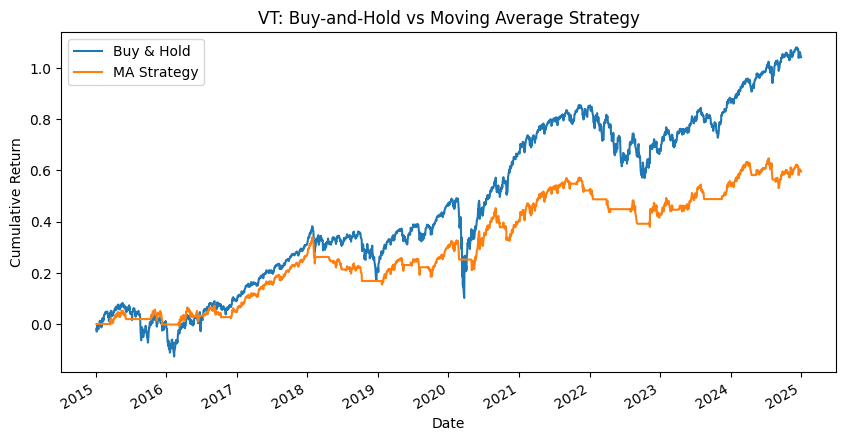

VT Buy-and-Hold Total Return: 104.18%
VT MA Strategy Total Return: 59.60%


In [5]:
# Download Vanguard Total World Stock ETF (VT) historical daily data
vt_data = yf.download("VT", start="2015-01-01", end="2025-01-01", auto_adjust=True)

# Extract closing prices
price_series = vt_data["Close"]

# Create main DataFrame
df = pd.DataFrame({
    "price": price_series.iloc[:, 0]
})

# Calculate daily returns
df["daily_return"] = df["price"].pct_change()

# Calculate moving averages
df["ma_10"] = df["price"].rolling(window=10).mean()
df["ma_50"] = df["price"].rolling(window=50).mean()

# Generate trading signal (1 = invested, 0 = cash)
df["signal"] = (df["ma_10"] > df["ma_50"]).astype(int)

# Strategy returns (shift signal to avoid lookahead bias)
df["strategy_return"] = df["signal"].shift(1) * df["daily_return"]

# Plot cumulative returns
cumulative_returns = df[["daily_return", "strategy_return"]].cumsum()
cumulative_returns.plot(figsize=(10, 5))

plt.title("VT: Buy-and-Hold vs Moving Average Strategy")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.legend(["Buy & Hold", "MA Strategy"])
plt.show()

# Compute final cumulative returns
buy_hold_total = cumulative_returns["daily_return"].iloc[-1]
strategy_total = cumulative_returns["strategy_return"].iloc[-1]

print(f"VT Buy-and-Hold Total Return: {buy_hold_total * 100:.2f}%")
print(f"VT MA Strategy Total Return: {strategy_total * 100:.2f}%")

It calculates daily returns and compares a buy-and-hold strategy with a moving-average rule that invests only when the 10-day average exceeds the 50-day average, signaling upward momentum. The model simulates when the strategy is in or out of the market and computes the resulting returns, then plots and reports the cumulative performance of both approaches.

Over the full period, buy-and-hold more than doubled the investment (104.18%), while the moving-average strategy achieved a lower return (59.60%). This indicates that the timing rule reduced overall gains rather than improving them.

The results illustrate the weak-form Efficient Market Hypothesis (Fama, 1970): past price data does not provide a consistent advantage. Both strategies track each other closely without sustained outperformance, which is consistent with a market where prices already reflect historical information.


In [6]:
lib_day_date = "2025-04-02"
vt_lib_day = yf.download("VT", start="2024-08-01", end="2025-12-01", auto_adjust=True)
df = vt_lib_day[["Close"]].rename(columns={"Close": "price"})
df["ret"] = df["price"].pct_change()
# Compute normal mean return
normal_mean = df["ret"].mean()

# Compute mean and std of returns
normal_mean = df["ret"].mean()
normal_std = df["ret"].std()

# Compute standardized deviation (z-score)
df["abnormal_z"] = (df["ret"] - normal_mean) / normal_std

# Flag extreme days (>2 standard deviations from mean)
df["extreme"] = df["abnormal_z"].abs() > 2



[*********************100%***********************]  1 of 1 completed


This code analyzes VT’s price behavior around Liberation Day by calculating daily returns and comparing them to the stock’s typical behavior. It standardizes each return into a z-score to measure how far it deviates from the normal mean and flags extreme outliers, days when the price moves unusually sharply, helping identify potentially significant market reactions.

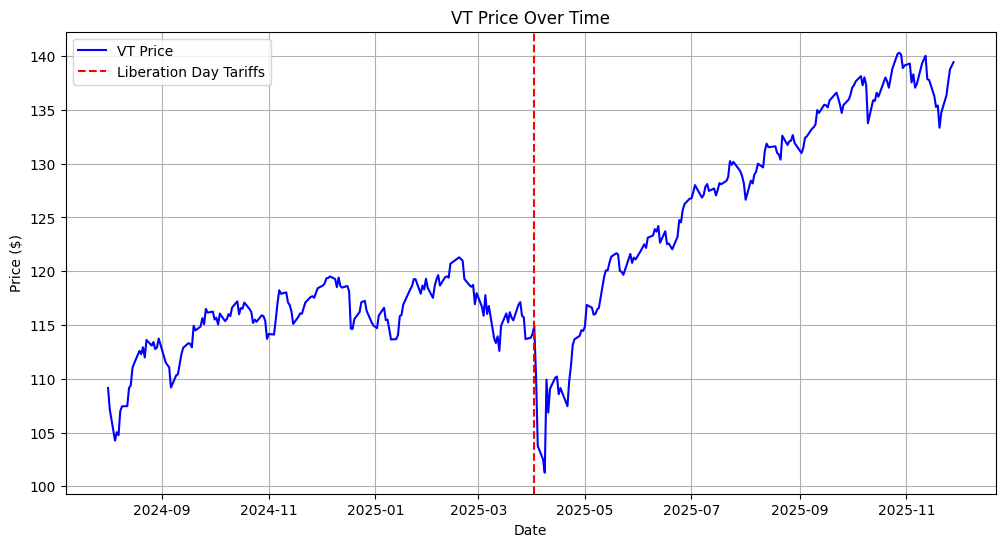

In [7]:
plt.figure(figsize=(12,6))
plt.plot(vt_lib_day.index, vt_lib_day["Close"], label="VT Price", color="blue")
plt.axvline(pd.to_datetime(lib_day_date), color="red", linestyle="--", label="Liberation Day Tariffs")
plt.title("VT Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(True)
plt.legend()
plt.show()

This chart illustrates how the market price moved following the announcement of the Liberation Day tariffs. We observe a significant downward movement immediately after the announcement. The rapid, sharp decline indicates that once the information became public, the market efficiently incorporated it into prices. This behavior is typical in real-world markets, where adjustments often occur quickly in response to unexpected news.

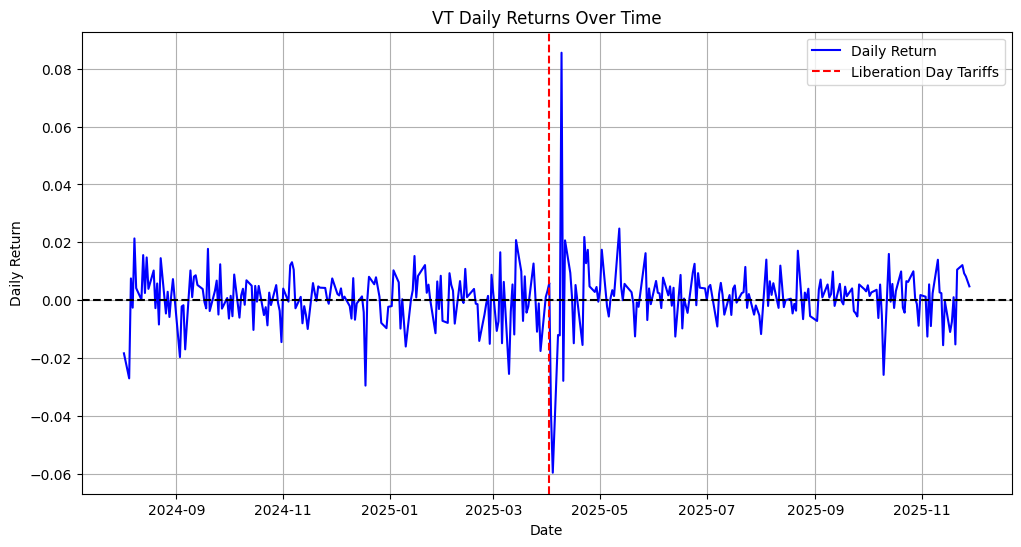

Daily Returns for the 2 days after Liberation Day event (in %):
2025-04-03: -3.95%
2025-04-04: -5.96%
Daily Returns for the 2 days before Liberation Day event (in %):
2025-03-31: +0.11%
2025-04-01: +0.33%


In [8]:
# Plot daily returns
plt.figure(figsize=(12,6))
plt.plot(df.index, df["ret"], label="Daily Return", color="blue")
plt.axvline(pd.to_datetime(lib_day_date), color="red", linestyle="--", label="Liberation Day Tariffs")
plt.axhline(0, color="black", linestyle="--")  # zero line for reference
plt.title("VT Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.legend()
plt.show()

# Make sure event date is a Timestamp
event_date = pd.to_datetime(lib_day_date)

# Find the index of the event date
event_idx = df.index.get_loc(event_date)
next_two_days_returns = df.iloc[event_idx + 1 : event_idx + 3]["ret"]
prior_two_days_returns = df.iloc[event_idx - 2 : event_idx]["ret"]

prior_formatted_returns = prior_two_days_returns.copy()
prior_formatted_returns = prior_formatted_returns * 100  # convert to percentage
prior_formatted_returns = prior_formatted_returns.round(2)  # round to 2 decimals
prior_formatted_returns.index = prior_formatted_returns.index.strftime("%Y-%m-%d")  # nice date format

# Format next two days' returns
following_formatted_returns = next_two_days_returns.copy()
following_formatted_returns = following_formatted_returns * 100  # convert to percentage
following_formatted_returns = following_formatted_returns.round(2)  # round to 2 decimals
following_formatted_returns.index = following_formatted_returns.index.strftime("%Y-%m-%d")  # nice date format

# Print neatly
print("Daily Returns for the 2 days after Liberation Day event (in %):")
for date, ret in following_formatted_returns.items():
    print(f"{date}: {ret:+.2f}%")

print("Daily Returns for the 2 days before Liberation Day event (in %):")
for date, ret in prior_formatted_returns.items():
    print(f"{date}: {ret:+.2f}%")

The plot shows VT ETF daily returns around the Liberation Day event on April 2, 2025. In the two days before the event, returns were slightly positive (+0.11% on March 31 and +0.33% on April 1), indicating relative stability. Immediately after the event, returns turned sharply negative, with -3.95% on April 3 and -5.96% on April 4, suggesting a strong market reaction. The red dashed line marks the event date, highlighting the sudden drop in returns following the event, while the zero line provides a reference for gains and losses.

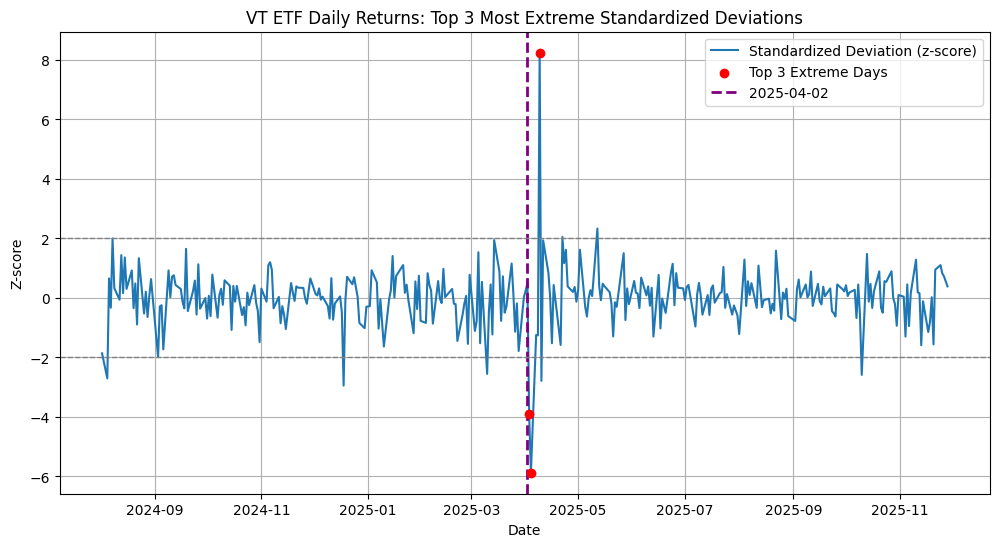

In [9]:
# Top 3 most extreme days by absolute z-score
top3_idx = df["abnormal_z"].abs().nlargest(3).index

# Plot all standardized deviations
plt.figure(figsize=(12,6))
plt.plot(df.index, df["abnormal_z"], label="Standardized Deviation (z-score)")

# Highlight only the top 3 extreme days
plt.scatter(df.index[df.index.isin(top3_idx)], df["abnormal_z"][df.index.isin(top3_idx)],
            color='red', label='Top 3 Extreme Days', zorder=5)

# Add vertical line for the specific day
plt.axvline(pd.to_datetime(lib_day_date), color='purple', linestyle='--', linewidth=2, label=f'{lib_day_date}')

# Reference lines for ±2 standard deviations
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

plt.title("VT ETF Daily Returns: Top 3 Most Extreme Standardized Deviations")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True)
plt.show()

The chart shows the daily returns of the VT ETF standardized as z-scores, which measure how far each day’s return deviates from the historical average in units of standard deviations. The blue line represents all daily deviations. The red dots highlight the top 3 most extreme days, showing when returns were unusually high or low. The dashed gray lines mark ±2 standard deviations, indicating the typical range of variation. Finally, the purple dashed line marks April 2, 2025, allowing us to see exactly where this specific day falls relative to the rest of the return distribution.